Load the CSV Data into a Pandas DataFrame

In [2]:
# Alternate version of cell 1 for Francesco (not using google colab)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv("listings.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1419,https://www.airbnb.com/rooms/1419,2.025110e+13,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.05
1,8077,https://www.airbnb.com/rooms/8077,2.025110e+13,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,...,4.90,4.92,4.83,NaN,f,2,1,1,0,0.85
2,26654,https://www.airbnb.com/rooms/26654,2.025110e+13,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,...,4.78,4.87,4.69,NaN,f,3,3,0,0,0.25
3,27423,https://www.airbnb.com/rooms/27423,2.025110e+13,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,...,5.00,4.88,4.88,NaN,f,1,1,0,0,0.16
4,30931,https://www.airbnb.com/rooms/30931,2.025110e+13,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,...,NaN,NaN,NaN,NaN,f,2,1,1,0,0.01


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("listings.csv")
df.head()

Basic Inspection

In [3]:
print("Shape of dataset:", df.shape)
print("\nFirst 10 column names:")
print(df.columns[:10].tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Shape of dataset: (21468, 79)

First 10 column names:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']

Data types:
id                                                int64
listing_url                                         str
scrape_id                                       float64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

Missing values (top 20):
neighbourhood_group_cleansed    21468
calendar_updated                21468
host_neighbourhood              14025
neighborhood_ove

Keeping only relevant columns

In [4]:
keep_cols = [
    "id",
    "name",
    "host_id",
    "host_response_time",
    "host_response_rate",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "amenities",
    "price",
    "minimum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "review_scores_rating",
    "review_scores_location",
    "review_scores_value",
    "instant_bookable",
    "calculated_host_listings_count",
    "reviews_per_month"
]

airbnb = df[keep_cols].copy()
airbnb.head()

,id,name,host_id,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,...,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month
0,1419,Beautiful home in amazing area!,1565,NaN,NaN,f,Little Portugal,43.64590,-79.42423,Entire home,...,6,0,0,NaN,5.00,5.00,5.00,f,1,0.05
1,8077,Downtown Harbourfront Private Room,22795,NaN,NaN,f,Waterfront Communities-The Island,43.64080,-79.37673,Private room in rental unit,...,167,0,0,NaN,4.83,4.92,4.83,f,2,0.85
2,26654,"World Class @ CN Tower, convention centre, The...",113345,within a few hours,91%,t,Waterfront Communities-The Island,43.64608,-79.39032,Entire condo,...,45,2,112,14896.0,4.80,4.87,4.69,f,3,0.25
3,27423,Executive Studio Unit- Ideal for One Person,118124,NaN,NaN,f,South Riverdale,43.66884,-79.32725,Entire rental unit,...,31,1,255,19125.0,4.93,4.88,4.88,f,1,0.16
4,30931,Downtown Toronto - Waterview Condo,22795,NaN,NaN,f,Waterfront Communities-The Island,43.64015,-79.37625,Entire rental unit,...,1,0,0,NaN,5.00,NaN,NaN,f,2,0.01


Clean price

In [5]:
airbnb["price"] = (
    airbnb["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
)

airbnb["price"] = pd.to_numeric(airbnb["price"], errors="coerce")
print(airbnb["price"].describe())

count    15809.000000
mean       176.304763
std        308.294008
min         12.000000
25%         76.000000
50%        125.000000
75%        201.000000
max      11185.000000
Name: price, dtype: float64


Clean host_response_rate

In [6]:
airbnb["host_response_rate"] = (
    airbnb["host_response_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

airbnb["host_response_rate"] = pd.to_numeric(airbnb["host_response_rate"], errors="coerce")
print(airbnb["host_response_rate"].describe())

count    14662.000000
mean        93.963920
std         18.795425
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64


Convert yes/no variables to numeric

In [7]:
airbnb["host_is_superhost"] = airbnb["host_is_superhost"].map({"t": 1, "f": 0})
airbnb["instant_bookable"] = airbnb["instant_bookable"].map({"t": 1, "f": 0})

print(airbnb[["host_is_superhost", "instant_bookable"]].head())

   host_is_superhost  instant_bookable
0                0.0                 0
1                0.0                 0
2                1.0                 0
3                0.0                 0
4                0.0                 0


Extract numeric bathrooms from bathrooms_text

In [8]:
def extract_bathrooms(text):
    if pd.isna(text):
        return np.nan
    match = re.search(r"(\d+(\.\d+)?)", str(text))
    return float(match.group(1)) if match else np.nan

airbnb["bathrooms_num"] = airbnb["bathrooms_text"].apply(extract_bathrooms)

# If bathrooms column is missing, fill with bathrooms_num
airbnb["bathrooms_clean"] = airbnb["bathrooms"]
airbnb["bathrooms_clean"] = airbnb["bathrooms_clean"].fillna(airbnb["bathrooms_num"])

airbnb[["bathrooms", "bathrooms_text", "bathrooms_num", "bathrooms_clean"]].head()

,bathrooms,bathrooms_text,bathrooms_num,bathrooms_clean
0,NaN,3 baths,3.0,3.0
1,NaN,1.5 baths,1.5,1.5
2,1.0,1 bath,1.0,1.0
3,1.0,1 bath,1.0,1.0
4,NaN,1.5 baths,1.5,1.5


Create amenities count

In [9]:
def count_amenities(x):
    if pd.isna(x):
        return 0
    # amenities are stored like: ["Wifi", "Kitchen", ...]
    items = str(x).strip("{}").split(",")
    return len(items)

airbnb["amenities_count"] = airbnb["amenities"].apply(count_amenities)

print(airbnb["amenities_count"].describe())

count    21468.000000
mean        35.090973
std         16.445963
min          1.000000
25%         22.000000
50%         36.000000
75%         47.000000
max        114.000000
Name: amenities_count, dtype: float64


Handle missing values

In [10]:
# Fill numeric columns with median where appropriate
fill_median_cols = [
    "bedrooms", "beds", "bathrooms_clean",
    "review_scores_rating", "review_scores_location",
    "review_scores_value", "reviews_per_month",
    "host_response_rate"
]

for col in fill_median_cols:
    airbnb[col] = airbnb[col].fillna(airbnb[col].median())

# Fill binary/flag columns with mode
airbnb["host_is_superhost"] = airbnb["host_is_superhost"].fillna(airbnb["host_is_superhost"].mode()[0])
airbnb["instant_bookable"] = airbnb["instant_bookable"].fillna(airbnb["instant_bookable"].mode()[0])

# Drop remaining rows missing critical variables
airbnb = airbnb.dropna(subset=["price", "latitude", "longitude", "room_type", "property_type", "neighbourhood_cleansed"])

print("Shape after cleaning:", airbnb.shape)
print("\nRemaining missing values:")
print(airbnb.isnull().sum().sort_values(ascending=False).head(20))

Shape after cleaning: (15809, 36)

Remaining missing values:
host_response_time        2808
bathrooms_num               84
bathrooms_text              15
bathrooms                   10
host_id                      0
name                         0
id                           0
host_response_rate           0
longitude                    0
property_type                0
neighbourhood_cleansed       0
host_is_superhost            0
accommodates                 0
room_type                    0
bedrooms                     0
beds                         0
amenities                    0
price                        0
minimum_nights               0
latitude                     0
dtype: int64


Remove extreme price outliers for EDA

In [11]:
q1 = airbnb["price"].quantile(0.25)
q3 = airbnb["price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

airbnb_eda = airbnb[(airbnb["price"] >= lower_bound) & (airbnb["price"] <= upper_bound)].copy()

print("Original rows:", airbnb.shape[0])
print("Rows after outlier filter for EDA:", airbnb_eda.shape[0])

Original rows: 15809
Rows after outlier filter for EDA: 14874


Summary stats

In [12]:
airbnb_eda[[
    "price", "accommodates", "bedrooms", "beds",
    "bathrooms_clean", "minimum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm",
    "estimated_occupancy_l365d", "review_scores_rating",
    "amenities_count"
]].describe()

,price,accommodates,bedrooms,beds,bathrooms_clean,minimum_nights,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,review_scores_rating,amenities_count
count,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000
mean,137.354511,3.093922,1.382614,1.694904,1.239546,21.879925,224.981848,34.616579,9.400229,89.757698,4.807234,37.578728
std,79.833385,1.829735,0.817411,1.023015,0.542641,27.533255,114.498166,66.668196,15.787486,92.992480,0.342847,15.538528
min,12.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,73.000000,2.000000,1.000000,1.000000,1.000000,2.000000,129.000000,1.000000,0.000000,0.000000,4.790000,27.000000
50%,119.000000,2.000000,1.000000,1.000000,1.000000,28.000000,246.000000,9.000000,2.000000,56.000000,4.890000,39.000000
75%,186.000000,4.000000,2.000000,2.000000,1.000000,28.000000,341.000000,40.000000,13.000000,168.000000,4.980000,48.000000
max,388.000000,16.000000,10.000000,11.000000,20.000000,888.000000,365.000000,1287.000000,395.000000,255.000000,5.000000,105.000000


Price distribution

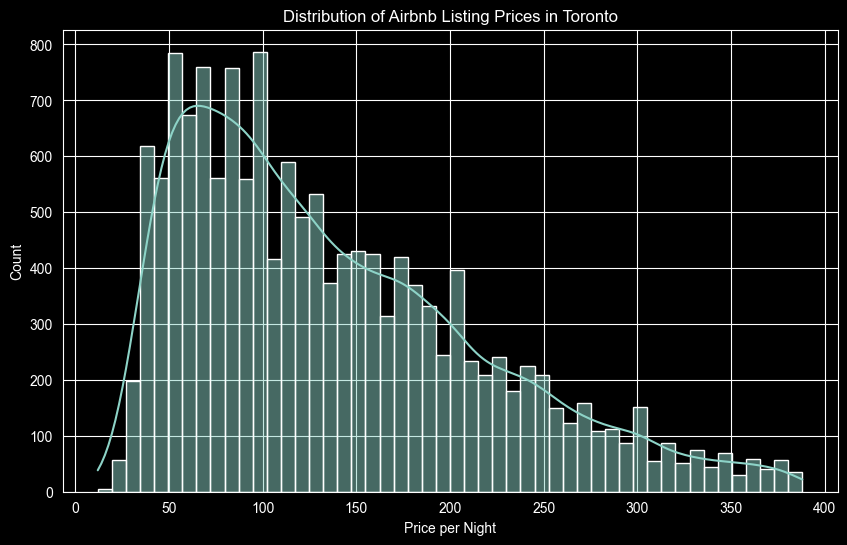

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(airbnb_eda["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Listing Prices in Toronto")
plt.xlabel("Price per Night")
plt.ylabel("Count")
plt.show()

Price by room type

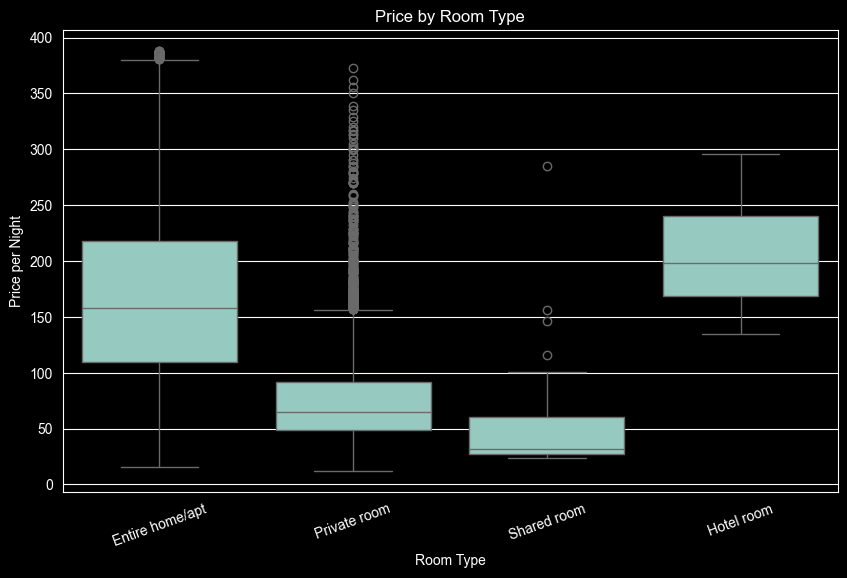

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=airbnb_eda, x="room_type", y="price")
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per Night")
plt.xticks(rotation=20)
plt.show()

Top neighbourhoods by average price

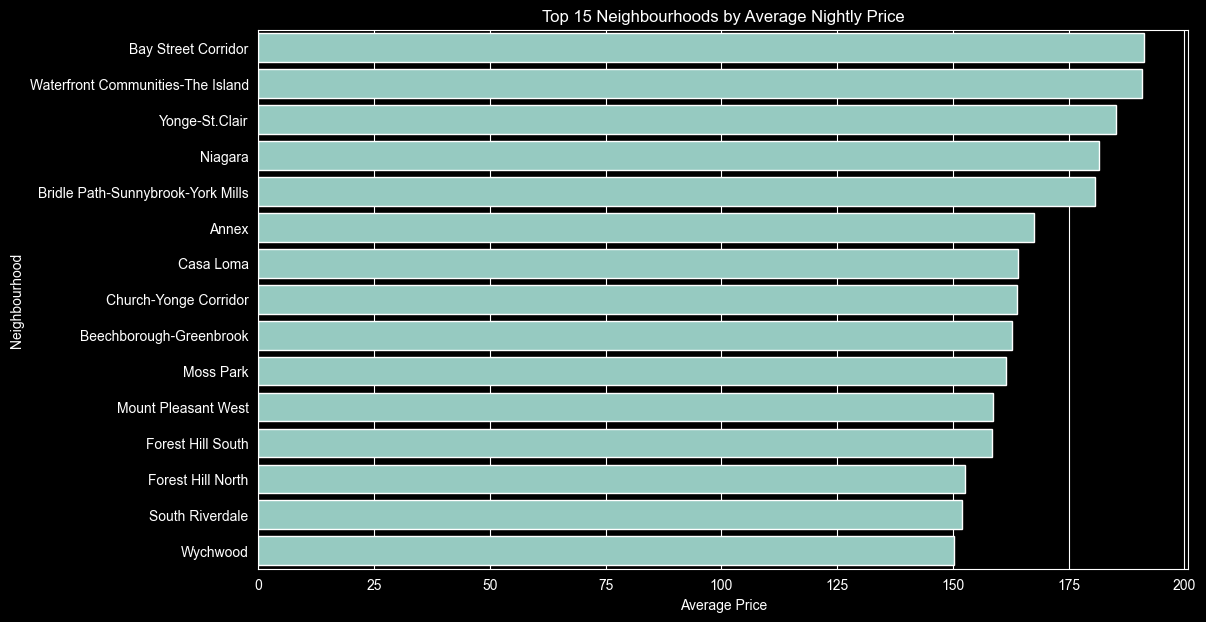

In [15]:
top_neighbourhoods = (
    airbnb_eda.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_neighbourhoods, x="price", y="neighbourhood_cleansed")
plt.title("Top 15 Neighbourhoods by Average Nightly Price")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")
plt.show()

Top neighbourhoods by occupancy proxy

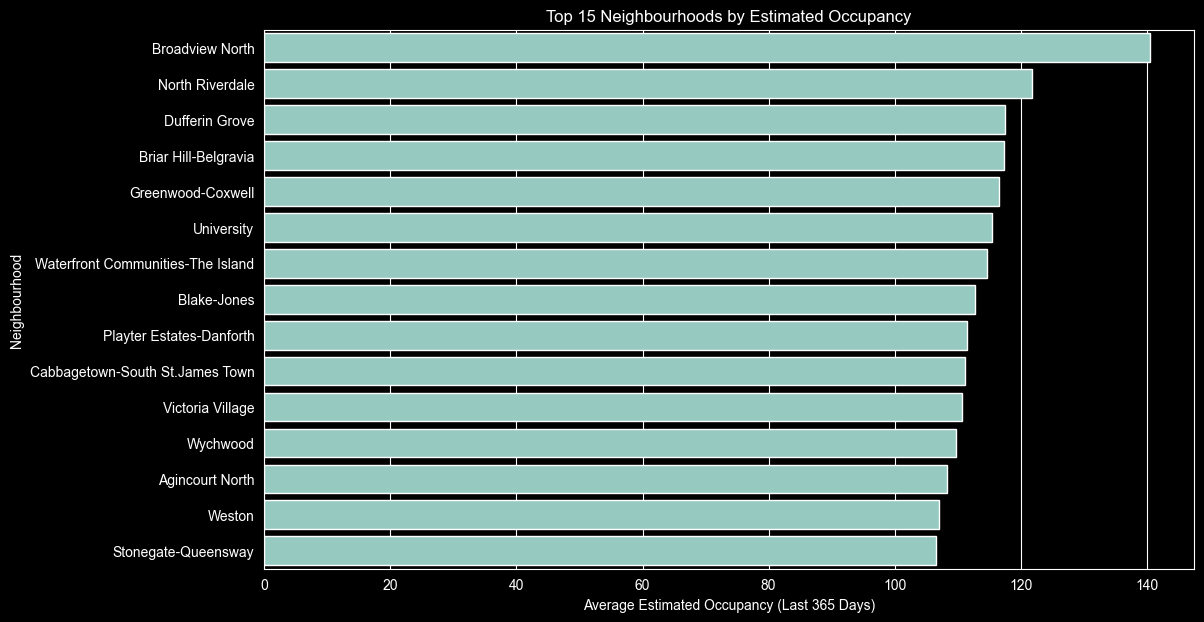

In [16]:
top_occupancy = (
    airbnb_eda.groupby("neighbourhood_cleansed")["estimated_occupancy_l365d"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_occupancy, x="estimated_occupancy_l365d", y="neighbourhood_cleansed")
plt.title("Top 15 Neighbourhoods by Estimated Occupancy")
plt.xlabel("Average Estimated Occupancy (Last 365 Days)")
plt.ylabel("Neighbourhood")
plt.show()

Price vs accommodates

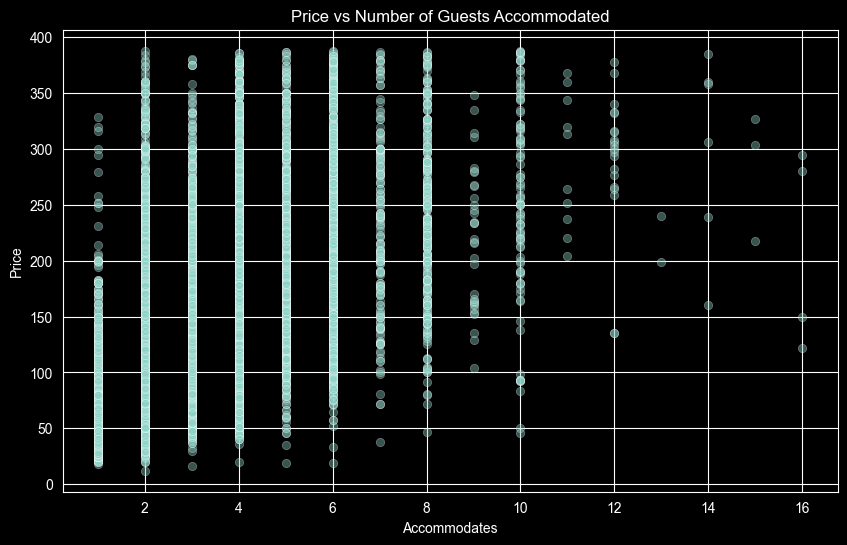

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airbnb_eda, x="accommodates", y="price", alpha=0.4)
plt.title("Price vs Number of Guests Accommodated")
plt.xlabel("Accommodates")
plt.ylabel("Price")
plt.show()

Correlation heatmap

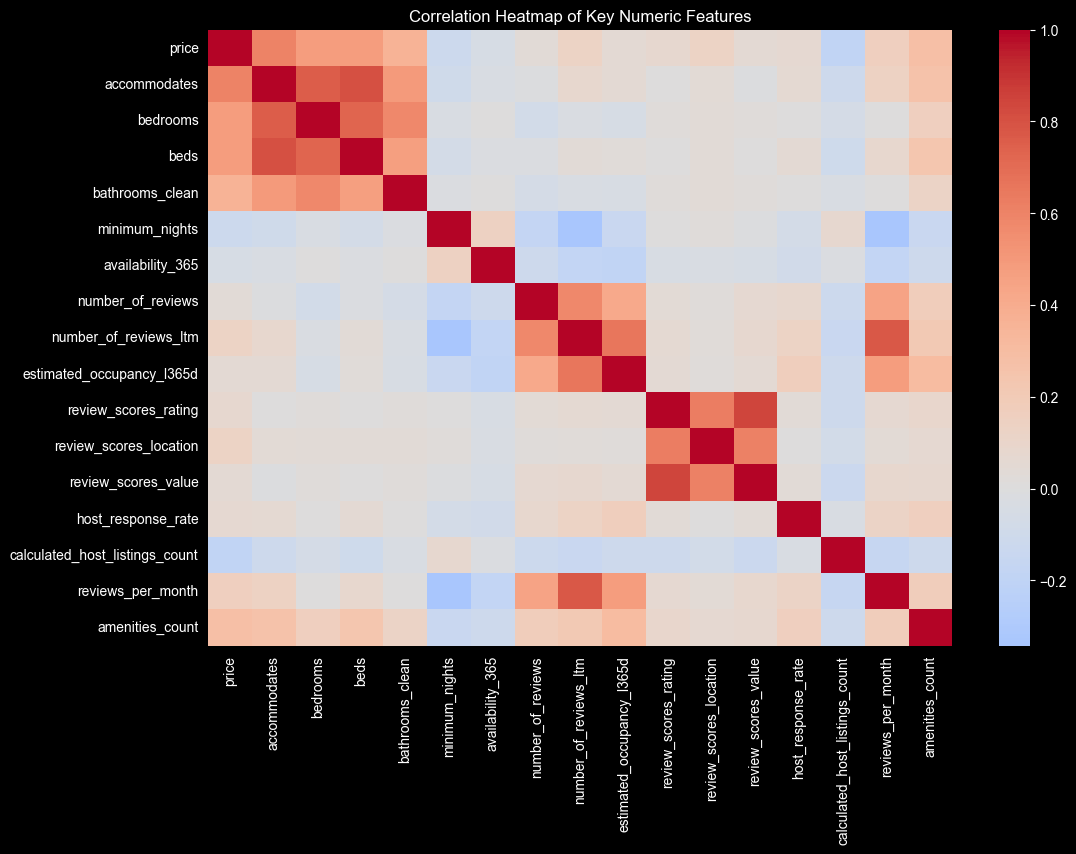

In [18]:
numeric_cols = [
    "price", "accommodates", "bedrooms", "beds", "bathrooms_clean",
    "minimum_nights", "availability_365", "number_of_reviews",
    "number_of_reviews_ltm", "estimated_occupancy_l365d",
    "review_scores_rating", "review_scores_location",
    "review_scores_value", "host_response_rate",
    "calculated_host_listings_count", "reviews_per_month",
    "amenities_count"
]

corr = airbnb_eda[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Numeric Features")
plt.show()

Geographic scatterplot of listings by price

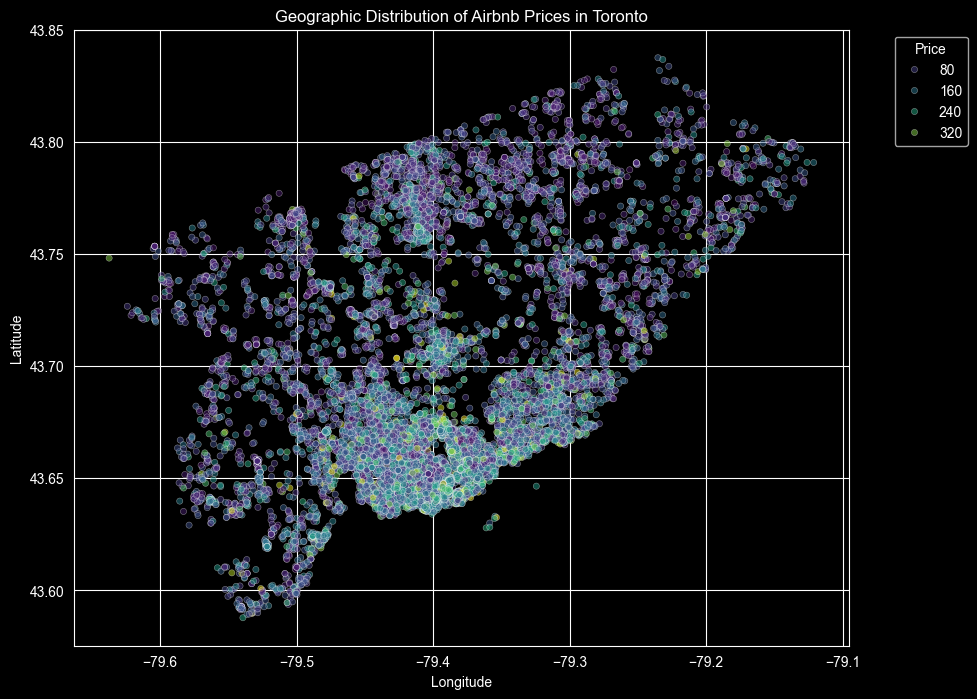

In [19]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=airbnb_eda,
    x="longitude",
    y="latitude",
    hue="price",
    palette="viridis",
    alpha=0.5,
    s=20
)
plt.title("Geographic Distribution of Airbnb Prices in Toronto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Price", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Room type share

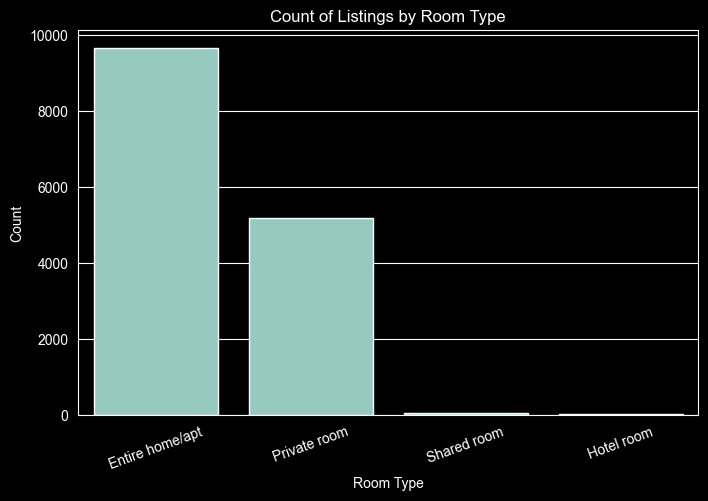

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=airbnb_eda, x="room_type", order=airbnb_eda["room_type"].value_counts().index)
plt.title("Count of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

Superhost vs non-superhost price comparison

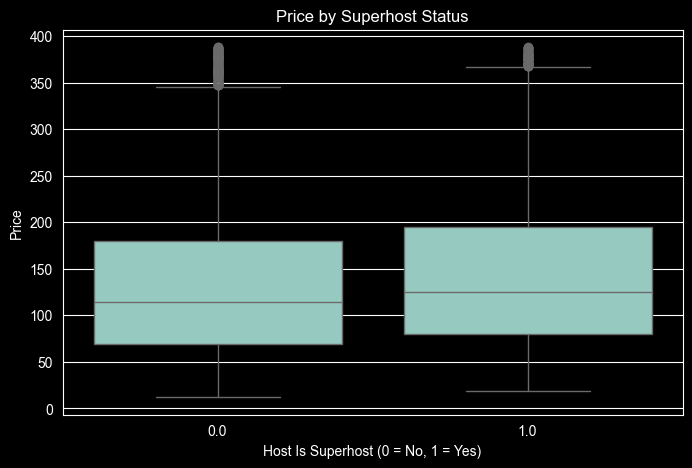

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=airbnb_eda, x="host_is_superhost", y="price")
plt.title("Price by Superhost Status")
plt.xlabel("Host Is Superhost (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.show()

**SAVE the cleaned file**

In [ ]:
airbnb.to_csv("airbnb_toronto_cleaned.csv", index=False)
files.download("airbnb_toronto_cleaned.csv")

**KEY INSIGHTS**
- Airbnb prices in Toronto are highly right-skewed.
- Entire homes command significantly higher prices than private/shared rooms.
- Location plays a major role in pricing, with certain neighbourhoods showing clear price premiums.
- Listing size and capacity (accommodates, bedrooms) are important drivers of price.
- Occupancy-related variables suggest variation in demand across neighbourhoods.

Encoding

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# a function to group all rare property types into an 'other' category for OneHotEncoding

counts = airbnb['property_type'].value_counts()
def replace_rare(x):
    threshold = 100
    if counts[x] >= threshold:
        return x
    else:
        return 'Other'

airbnb['property_type'] = airbnb['property_type'].apply(replace_rare)

feature_cols = [
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms_clean',
    'amenities_count',
    'minimum_nights',
    'review_scores_rating',
    'review_scores_location',
    'review_scores_value',
    'host_is_superhost',
    'instant_bookable',
    'host_response_rate',
    'calculated_host_listings_count',
    'neighbourhood_cleansed'
]

x = airbnb[feature_cols]
y=np.log1p(airbnb['price']) #log-scaling for hugely skewed price distribution

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
oneHotCols = ['room_type', 'property_type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(x_train[oneHotCols])

x_train['neighbourhood_encoded'] = x_train['neighbourhood_cleansed'].map(
    y_train.groupby(x_train['neighbourhood_cleansed']).mean()
)
x_test['neighbourhood_encoded'] = x_test['neighbourhood_cleansed'].map(
    y_train.groupby(x_train['neighbourhood_cleansed']).mean()
)

x_train = x_train.drop(columns=['neighbourhood_cleansed'])
x_test = x_test.drop(columns=['neighbourhood_cleansed'])

encoded_train = pd.DataFrame(
    encoder.transform(x_train[oneHotCols]),
    columns=encoder.get_feature_names_out(oneHotCols),
    index=x_train.index
)

encoded_test = pd.DataFrame(
    encoder.transform(x_test[oneHotCols]),
    columns=encoder.get_feature_names_out(oneHotCols),
    index=x_test.index
)

x_train = x_train.drop(columns=oneHotCols)
x_test = x_test.drop(columns=oneHotCols)

x_train = pd.concat([x_train, encoded_train], axis=1)
x_test = pd.concat([x_test, encoded_test], axis=1)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train
lr = LinearRegression()
lr.fit(x_train, y_train)

# Predict
y_pred_lr = lr.predict(x_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lr)))
r2 = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

RMSE: 225.05
R²: 0.6185


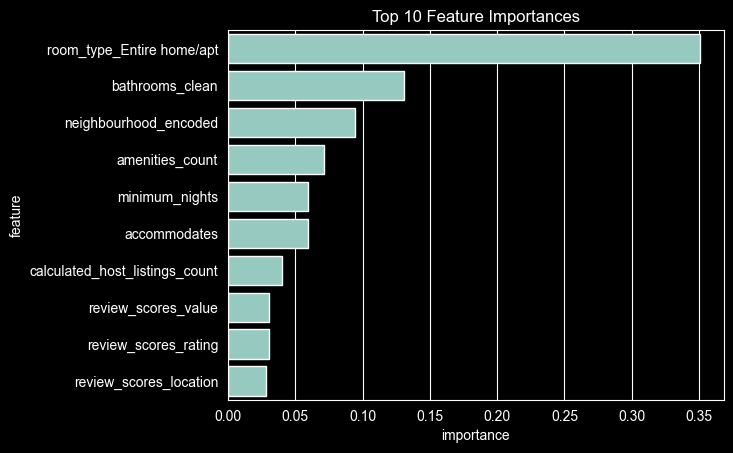

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

importances = rf.feature_importances_
featureNames = x_train.columns

importanceDF = pd.DataFrame({'feature': featureNames, 'importance': importances})
importanceDF = importanceDF.sort_values('importance', ascending=False).head(10)

sns.barplot(data=importanceDF, x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.show()

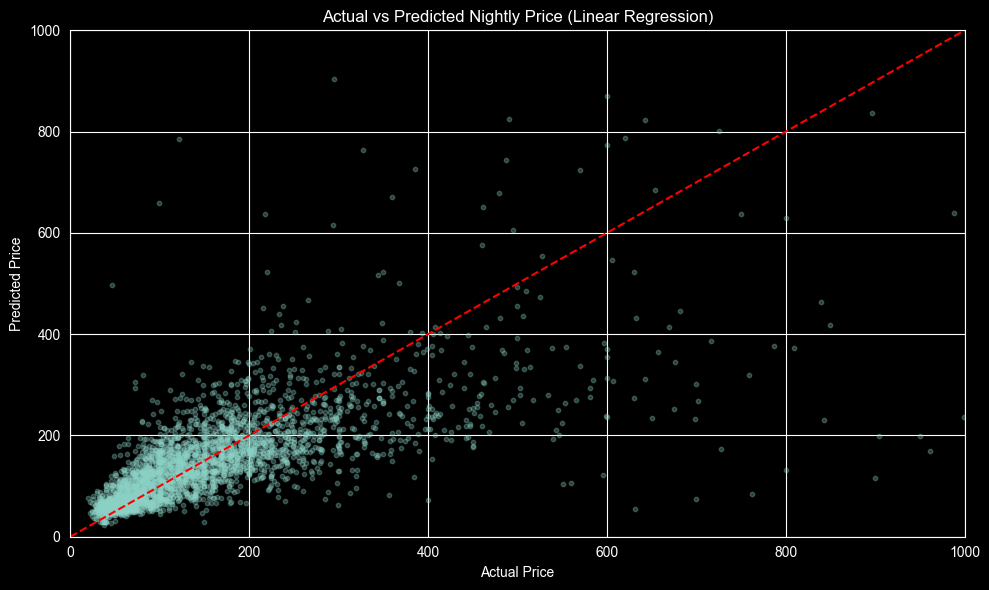

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_pred_lr), alpha=0.3, s=10)
plt.plot([0, 1000], [0, 1000], color='red', linewidth=1.5, linestyle='--')  # perfect prediction line
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Nightly Price (Linear Regression)")
plt.tight_layout()
plt.show()